# K-Means Clustering

## What Is K-Means?

K-Means answers: *"Given this unlabeled data, how do I divide it into K groups such that every point is as close as possible to the center of its group?"*

It alternates between two steps until the assignments stop changing:
1. **Assign** each point to the nearest centroid (center of a cluster)
2. **Update** each centroid to be the mean of all points currently assigned to it

This is guaranteed to reduce (or maintain) the **Within-Cluster Sum of Squares (WCSS)** at every step:

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{i \in C_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

## 1. Setup & Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.unsupervised_learning.kmeans import kmeans
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

CSV_PATH = 'customer_segments.csv'

if not os.path.exists(CSV_PATH):
    # Generate 5 clusters representing customer archetypes
    # Centers chosen to mimic realistic income/spending patterns
    centers = [
        [30, 20],   # low income, low spending
        [30, 80],   # low income, high spending
        [60, 50],   # medium income, medium spending
        [90, 20],   # high income, low spending
        [90, 80],   # high income, high spending
    ]
    X_raw, y_true = make_blobs(
        n_samples=250, centers=centers,
        cluster_std=6.0, random_state=42
    )
    # Clip to realistic ranges
    X_raw[:, 0] = np.clip(X_raw[:, 0], 5, 140)   # income
    X_raw[:, 1] = np.clip(X_raw[:, 1], 1, 100)   # spending score

    df_out = pd.DataFrame(X_raw, columns=['income', 'spending_score'])
    df_out['true_cluster'] = y_true
    df_out.to_csv(CSV_PATH, index=False)
    print(f'Dataset generated and saved ({len(df_out)} samples, 5 clusters).')
else:
    print('Dataset already present.')

df = pd.read_csv(CSV_PATH)
X_raw  = df[['income', 'spending_score']].values
y_true = df['true_cluster'].values
print(f'Shape: {df.shape}')
print(f'Samples per true cluster: {pd.Series(y_true).value_counts().sort_index().to_dict()}')

Dataset already present.
Shape: (250, 3)
Samples per true cluster: {0: 50, 1: 50, 2: 50, 3: 50, 4: 50}


## 2. Explore the Raw Data

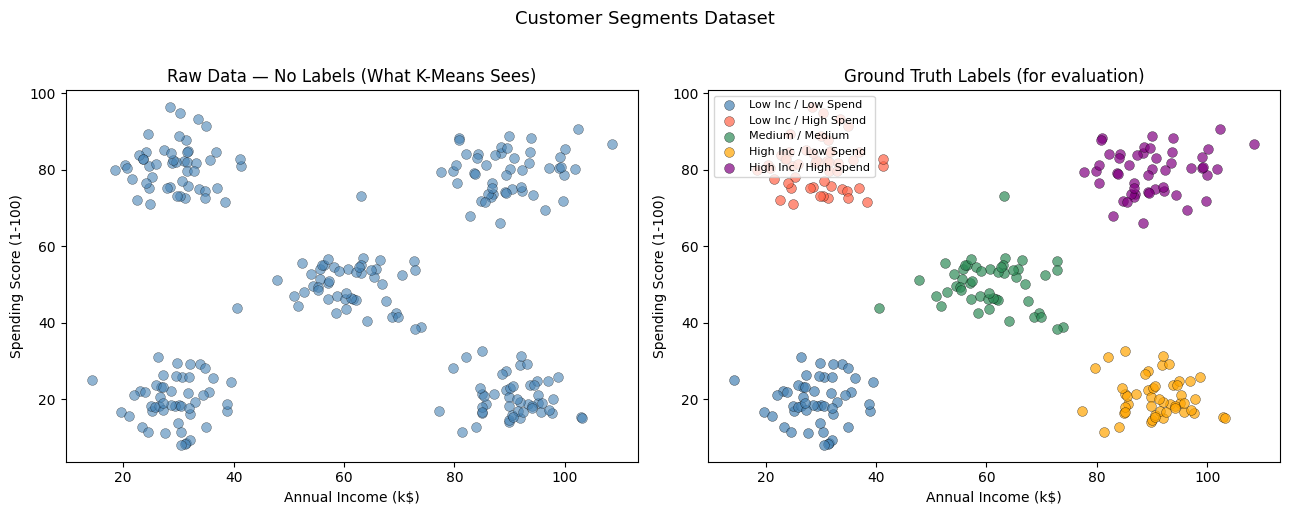

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: unlabeled (what K-Means sees)
axes[0].scatter(X_raw[:, 0], X_raw[:, 1],
                color='steelblue', alpha=0.6, s=50,
                edgecolors='k', linewidths=0.3)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('Raw Data — No Labels (What K-Means Sees)')

# Right: ground truth
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'purple']
segment_names = ['Low Inc / Low Spend', 'Low Inc / High Spend',
                 'Medium / Medium', 'High Inc / Low Spend', 'High Inc / High Spend']
for k in range(5):
    mask = y_true == k
    axes[1].scatter(X_raw[mask, 0], X_raw[mask, 1],
                    color=colors[k], alpha=0.7, s=50,
                    edgecolors='k', linewidths=0.3,
                    label=segment_names[k])
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].set_title('Ground Truth Labels (for evaluation)')
axes[1].legend(fontsize=8, loc='upper left')

plt.suptitle('Customer Segments Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The left plot shows what K-Means actually receives: no colors, no group labels. The algorithm must discover the structure from geometry alone.

The plot on the right shows the ground truth: the five generating clusters are revealed. Each color is a distinct customer archetype defined by income level
and spending behavior.

## 3. Preprocessing

K-Means computes Euclidean distances. Even though both features are already in similar ranges here, StandardScaler is applied as best practice. On real data, income might range 0–150 while spending score is 1–100, making unscaled distances meaningless.

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'After scaling — Mean: {X.mean(axis=0).round(4)}, Std: {X.std(axis=0).round(4)}')

After scaling — Mean: [ 0. -0.], Std: [1. 1.]


## 4. The Elbow Method — Choosing K

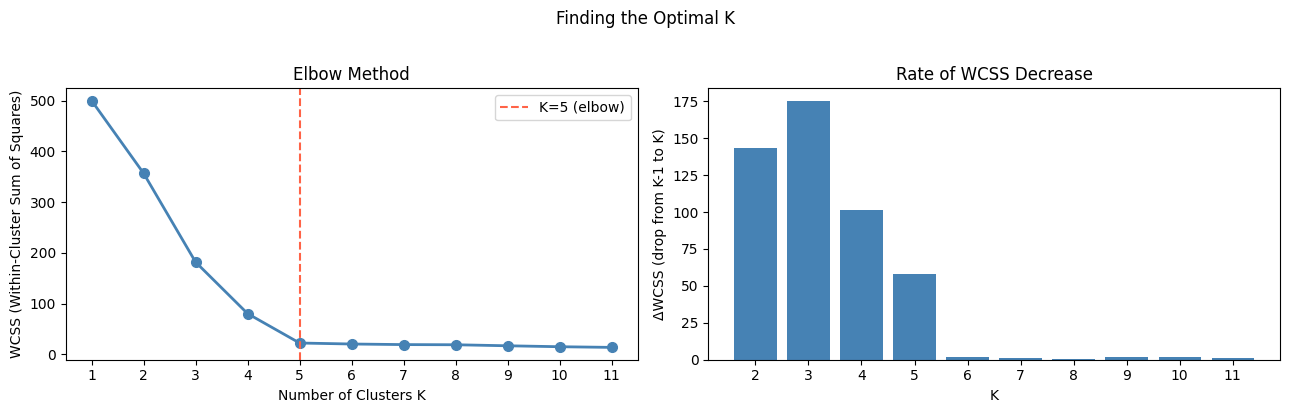

In [4]:
K_range = range(1, 12)
wcss_values = []

for k in K_range:
    km = kmeans(k=k, random_state=42)
    km.fit(X)
    wcss_values.append(km.inertia_)

# Compute rate of change to help locate elbow
deltas = [wcss_values[i] - wcss_values[i+1] for i in range(len(wcss_values)-1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), wcss_values, 'o-',
             color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(5, color='tomato', linestyle='--', linewidth=1.5, label='K=5 (elbow)')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))
axes[0].legend()

axes[1].bar(range(2, 12), deltas, color='steelblue')
axes[1].set_xlabel('K')
axes[1].set_ylabel('ΔWCSS (drop from K-1 to K)')
axes[1].set_title('Rate of WCSS Decrease')
axes[1].set_xticks(range(2, 12))

plt.suptitle('Finding the Optimal K', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The plot of the left shows the Elbow curve.
- X-axis represents how many clusters we ask K-Means to find.
- Y-axis shows total compactness (WCSS). Lower value = tighter clusters.

WCSS always falls as K increases (at K=n, every point is its own cluster and WCSS=0), so we cannot use WCSS alone to choose K.  
The 'elbow' is where the curve bends. Adding one more cluster gives much less improvement than before. Here the bend is at K=5.  

The plot on the right shows Rate of decrease (ΔWCSS).  
Each bar is how much WCSS dropped when going from K-1 to K clusters.  
A sharp drop followed by much smaller drops = the elbow.  
The tallest bars are at K=2,3,4,5; after K=5 the bars shrink dramatically, confirming the elbow. This view makes the elbow unambiguous when the main curve looks gradual.

## 5. Fitting K=5 and Visualizing the Result

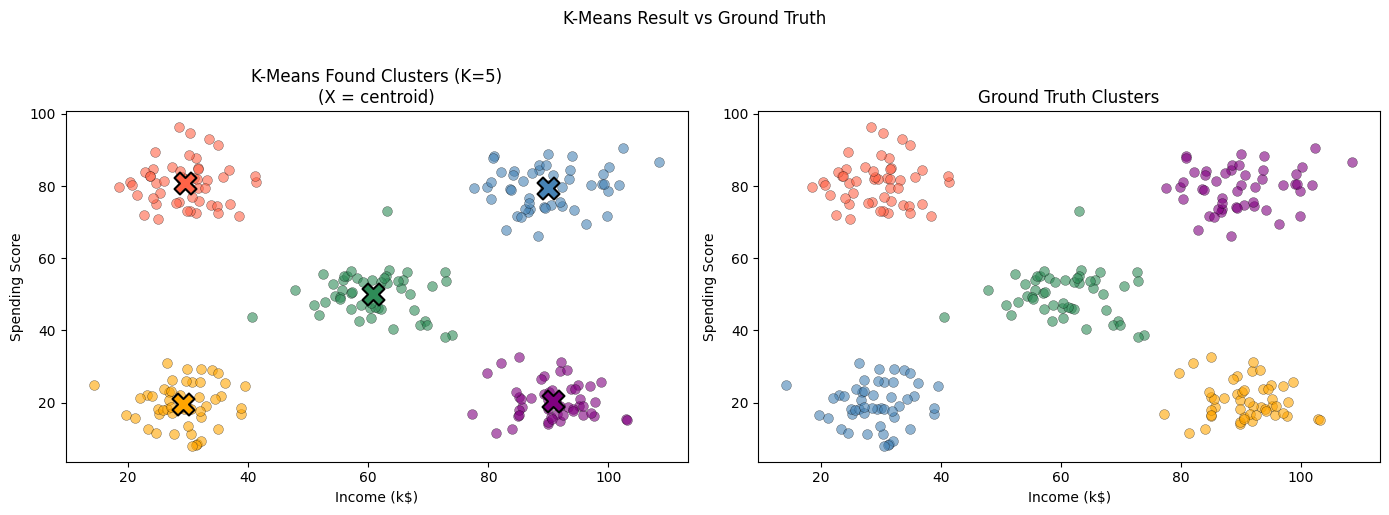

Cluster centroids (original scale):
  Cluster 0: Income=$89.9k, Spending Score=79.4
  Cluster 1: Income=$29.4k, Spending Score=80.8
  Cluster 2: Income=$60.8k, Spending Score=50.0
  Cluster 3: Income=$29.2k, Spending Score=19.6
  Cluster 4: Income=$90.8k, Spending Score=20.5


In [5]:
km5 = kmeans(k=5, random_state=42)
km5.fit(X)
labels_found = km5.predict(X)

# Centroids back in original scale
centroids_orig = scaler.inverse_transform(km5.centroids_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Found clusters
for k in range(5):
    mask = labels_found == k
    axes[0].scatter(X_raw[mask, 0], X_raw[mask, 1],
                    color=colors[k], alpha=0.6, s=50,
                    edgecolors='k', linewidths=0.3)
    axes[0].scatter(centroids_orig[k, 0], centroids_orig[k, 1],
                    color=colors[k], s=250, marker='X',
                    edgecolors='black', linewidths=1.5, zorder=5)
axes[0].set_xlabel('Income (k$)'); axes[0].set_ylabel('Spending Score')
axes[0].set_title('K-Means Found Clusters (K=5)\n(X = centroid)')

# Ground truth for comparison
for k in range(5):
    mask = y_true == k
    axes[1].scatter(X_raw[mask, 0], X_raw[mask, 1],
                    color=colors[k], alpha=0.6, s=50,
                    edgecolors='k', linewidths=0.3)
axes[1].set_xlabel('Income (k$)'); axes[1].set_ylabel('Spending Score')
axes[1].set_title('Ground Truth Clusters')

plt.suptitle('K-Means Result vs Ground Truth', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Cluster centroids (original scale):')
for k in range(5):
    print(f'  Cluster {k}: Income=${centroids_orig[k,0]:.1f}k, '
          f'Spending Score={centroids_orig[k,1]:.1f}')

The left plot shows the K-Means result, where colors were assigned by the algorithm.  
X marks the centroid (mean position) of each cluster. The centroid is equidistant from all members in all directions. It is the 'average customer' of that segment.

On the right we see the ground truth, the known generating clusters (cluster labels are arbitrary).  

The boundary between any two clusters is a straight line (the perpendicular bisector between the two centroids). This is the Voronoi cell decomposition.

## 6. Silhouette Score

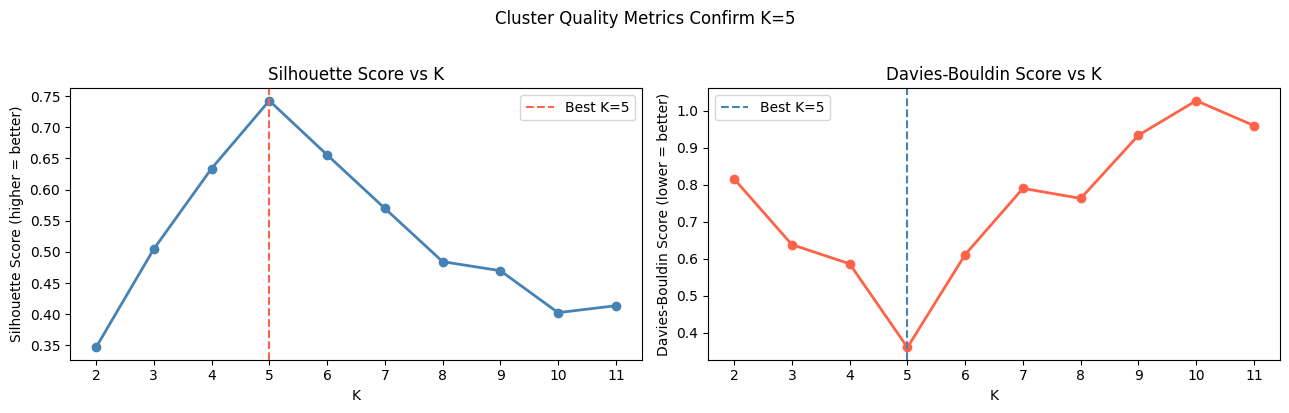

Best K (Silhouette):      5  (score=0.743)
Best K (Davies-Bouldin):  5  (score=0.361)


In [6]:
K_range2 = range(2, 12)
sil_scores = []
db_scores  = []

for k in K_range2:
    km = kmeans(k=k, random_state=42)
    km.fit(X)
    labs = km.predict(X)
    sil_scores.append(silhouette_score(X, labs))
    db_scores.append(davies_bouldin_score(X, labs))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range2), sil_scores, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(list(K_range2)[np.argmax(sil_scores)], color='tomato',
                linestyle='--', label=f'Best K={list(K_range2)[np.argmax(sil_scores)]}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Silhouette Score (higher = better)')
axes[0].set_title('Silhouette Score vs K')
axes[0].set_xticks(list(K_range2)); axes[0].legend()

axes[1].plot(list(K_range2), db_scores, 'o-', color='tomato', linewidth=2)
axes[1].axvline(list(K_range2)[np.argmin(db_scores)], color='steelblue',
                linestyle='--', label=f'Best K={list(K_range2)[np.argmin(db_scores)]}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Davies-Bouldin Score (lower = better)')
axes[1].set_title('Davies-Bouldin Score vs K')
axes[1].set_xticks(list(K_range2)); axes[1].legend()

plt.suptitle('Cluster Quality Metrics Confirm K=5', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Best K (Silhouette):      {list(K_range2)[np.argmax(sil_scores)]}  '
      f'(score={max(sil_scores):.3f})')
print(f'Best K (Davies-Bouldin):  {list(K_range2)[np.argmin(db_scores)]}  '
      f'(score={min(db_scores):.3f})')

Silhouette score (left plot):  
    For each point, it measures how similar is the point to its own cluster vs the nearest other cluster?  
     - +1.0: deeply inside its cluster, far from others (ideal)  
     - 0.0: on the boundary between two clusters  
     - -1.0: probably in the wrong cluster  
    The score is averaged over all points. Higher score = better-defined clusters.  
    The peak of this curve is the most statistically justified K.  

Davies-Bouldin score (right plot):  
    This is the average ratio of within-cluster scatter to between-cluster separation.  
    Lower value = clusters are compact and well-separated. Minimum = best K.

Both metrics should agree with the elbow and here they confirm K=5. When elbow and silhouette disagree, we should prefer silhouette, since it has no free parameter and makes a direct geometric statement.

## 7. Sensitivity to Initialization

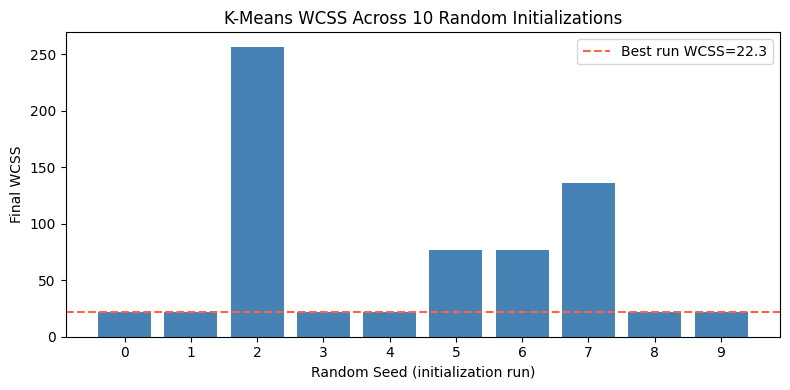

WCSS range: 22.28 — 256.61
Std across runs: 72.69


In [7]:
wcss_runs = []
n_runs = 10

for seed in range(n_runs):
    km = kmeans(k=5, random_state=seed)
    km.fit(X)
    wcss_runs.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(n_runs), wcss_runs, color='steelblue')
ax.axhline(min(wcss_runs), color='tomato', linestyle='--',
           label=f'Best run WCSS={min(wcss_runs):.1f}')
ax.set_xlabel('Random Seed (initialization run)')
ax.set_ylabel('Final WCSS')
ax.set_title('K-Means WCSS Across 10 Random Initializations')
ax.set_xticks(range(n_runs))
ax.legend()
plt.tight_layout()
plt.show()

print(f'WCSS range: {min(wcss_runs):.2f} — {max(wcss_runs):.2f}')
print(f'Std across runs: {np.std(wcss_runs):.2f}')

In this chart, each bar is one independent run of K-Means from a different random starting point for the centroids.  

K-Means is not convex, i.e. different starting positions can lead to different local minima with different WCSS values.  
The dashed line shows the best result found across all runs.

When the bars are all very similar, initialization sensitivity is low. Any starting point finds the same good solution. When clusters overlap heavily, the variance increases and multiple restarts become essential. Thus, the best practice is to always run K-Means multiple times and keep the run with the lowest WCSS. 

## 8. K-Means Limitations

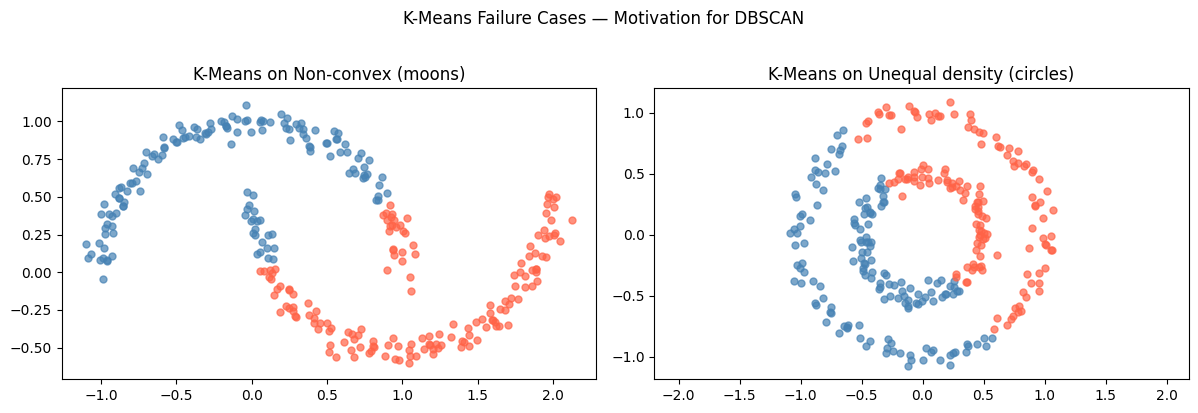

In [8]:
from sklearn.datasets import make_moons, make_circles

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cmap2 = ['steelblue', 'tomato']

for ax, (X_bad, title) in zip(axes, [
    (make_moons(300, noise=0.05, random_state=0)[0],   'Non-convex (moons)'),
    (make_circles(300, noise=0.05, factor=0.5, random_state=0)[0], 'Unequal density (circles)'),
]):
    X_bad_s = StandardScaler().fit_transform(X_bad)
    km_bad = kmeans(k=2, random_state=42)
    km_bad.fit(X_bad_s)
    labs = km_bad.predict(X_bad_s)
    for k in range(2):
        ax.scatter(X_bad[labs==k, 0], X_bad[labs==k, 1],
                   color=cmap2[k], alpha=0.7, s=25)
    ax.set_title(f'K-Means on {title}')
    ax.axis('equal')

plt.suptitle('K-Means Failure Cases — Motivation for DBSCAN', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Both datasets above have exactly 2 obvious clusters, but K-Means gets both wrong.  

Moons (left) shows two crescent shapes that are non-convex. K-Means always produces Voronoi cells, which are regions bounded by straight lines equidistant from two centroids. No straight-line boundary can separate crescents, so K-Means bisects each crescent in half instead.

Circles (right) shows one dense inner cluster surrounded by a sparse outer ring. K-Means assumes roughly equal density. It draws the boundary through the middle of the space rather than between inner and outer ring.

Both failures have the same root cause: K-Means assumes cluster shape is spherical (Euclidean nearest-centroid), which is wrong here.  
DBSCAN, which connects nearby points regardless of centroid distance, handles both shapes natively.

## 9. Key Takeaways

- The **elbow plot + rate-of-decrease bar chart** work together: the elbow curve shows where improvement slows; the bar chart makes the drop-off explicit and quantified.
- The **silhouette score** is a more rigorous confirmation of the elbow choice. When elbow is ambiguous, silhouette is the tiebreaker.
- **Centroids in the result plot** represent the 'average member' of each cluster in feature space. Their position in original scale gives a human-readable description of each segment.
- **Initialization sensitivity** is real but manageable: for well-separated clusters it barely matters. For overlapping clusters, we should always use multiple restarts and keep the lowest-WCSS solution.
- The **failure cases** reveal K-Means' core assumption (spherical Voronoi cells) and directly motivate DBSCAN, which discovers clusters by density rather than distance to a fixed centroid.

## Why K-Means?

Clustering is fundamentally about discovering unlabeled groupings, which makes this synthetic data with known ground truth the ideal choice:

- **Known answer**: because the data is generated from 5 Gaussian blobs, we know the true K=5. This lets us verify that the elbow method and silhouette score arrive at the right answer, rather than hoping they do.
- **2 features** (income-like, spending-like): all geometric concepts (centroids, Voronoi cells, cluster boundaries) are fully visible in a 2D scatter plot with no information loss.